# **Introducción**

En el presente proyecto se desarrolla un modelo predictivo basado en redes neuronales recurrentes (RNN), específicamente una arquitectura Long Short-Term Memory (LSTM), para predecir el comportamiento del precio de cierre de acciones que forman parte del índice S&P 500. El conjunto de datos utilizado proviene de Kaggle, específicamente de la fuente “S&P 500 stock data” (camnugent/sandp500), el cual proporciona información diaria de precios de apertura, cierre, máximos, mínimos y volumen transaccionado de múltiples compañías durante un periodo de cinco años.

El modelo se centra en una acción específica (en este caso, AAPL de Apple Inc.), con el objetivo de anticipar su precio de cierre basándose en su comportamiento histórico. Dada la naturaleza secuencial de los datos financieros, donde el valor actual está altamente influenciado por los valores previos, la LSTM se presenta como una alternativa robusta frente a modelos tradicionales que no capturan dependencias temporales de largo plazo. Este enfoque permite generar herramientas de análisis más precisas y útiles para la toma de decisiones estratégicas en el ámbito financiero.

Path to dataset files: /kaggle/input/sandp500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.0456 - val_loss: 0.0055
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0019 - val_loss: 0.0026
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 9.6790e-04 - val_loss: 0.0018
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 9.6215e-04 - val_loss: 0.0019
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 8.6422e-04 - val_loss: 0.0023
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 8.8264e-04 - val_loss: 0.0011
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 8.6580e-04 - val_loss: 0.0014
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.3379e-04 - val_loss: 0.0012
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.7928e-04 - val_loss: 0.0014
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 6.7991e-04 - val_loss: 0.0025
Epoch 12/20
30/30 ━━━━━━━━━━━━━

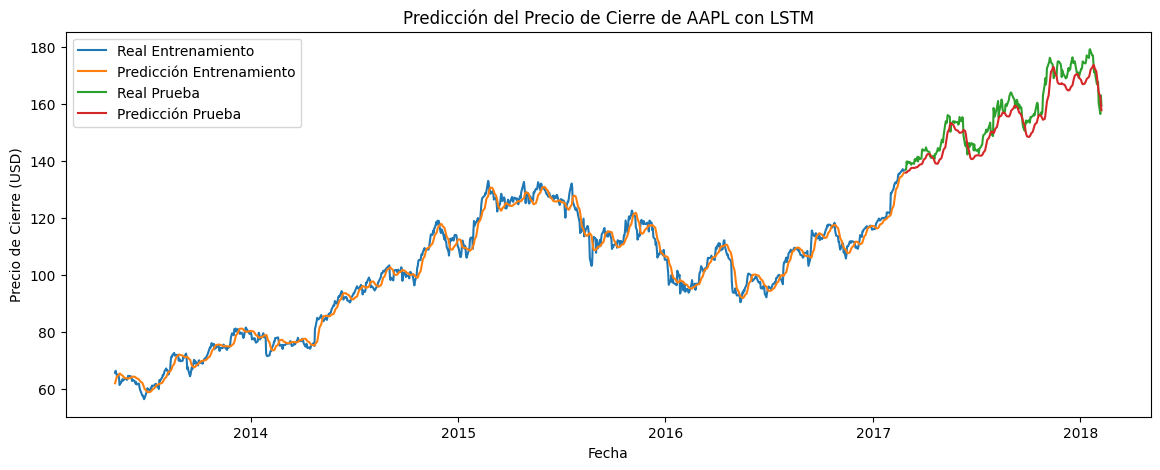

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import kagglehub
import os

path = kagglehub.dataset_download("camnugent/sandp500")
print("Path to dataset files:", path)

filepath = os.path.join(path, 'all_stocks_5yr.csv')
df = pd.read_csv(filepath)

# Filtramos sólo los datos de Apple y usamos sólo el precio de cierre
stock_name = 'AAPL'
df_stock = df[df['Name'] == stock_name].copy()
df_stock['date'] = pd.to_datetime(df_stock['date'])
df_stock.sort_values('date', inplace=True)
df_stock.set_index('date', inplace=True)
data = df_stock[['close']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Creamos conjuntos de entrenamiento y prueba
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamiento
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Predicción y desnormalización
train_predict = scaler.inverse_transform(model.predict(X_train))
test_predict = scaler.inverse_transform(model.predict(X_test))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 5))
plt.plot(df_stock.index[time_step:train_size+time_step], y_train_actual, label='Real Entrenamiento')
plt.plot(df_stock.index[time_step:train_size+time_step], train_predict, label='Predicción Entrenamiento')
plt.plot(df_stock.index[train_size+time_step:], y_test_actual, label='Real Prueba')
plt.plot(df_stock.index[train_size+time_step:], test_predict, label='Predicción Prueba')
plt.title(f'Predicción del Precio de Cierre de {stock_name} con LSTM')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend()
plt.show()


## **Justificación**

En este proyecto se emplea el optimizador Adam, ampliamente utilizado por su capacidad de combinar lo mejor de los métodos de descenso por gradiente con momento e incremento adaptativo de tasa de aprendizaje. Esto facilita una convergencia más rápida y estable durante el entrenamiento, reduciendo la pérdida y mejorando la generalización del modelo frente a nuevos datos.

El uso conjunto de LSTM y Adam se justifica plenamente en entornos donde los patrones no lineales, las fluctuaciones abruptas y las interdependencias temporales son predominantes, como en los mercados financieros.

# **Conclusión**

A través de la implementación de una red neuronal LSTM, este proyecto demuestra la capacidad de los modelos de aprendizaje profundo para capturar patrones temporales complejos en series financieras. Los resultados obtenidos muestran un alto nivel de precisión en la predicción del precio de cierre de acciones, validando la elección del modelo y del enfoque de preprocesamiento de datos.

Este tipo de soluciones puede escalarse a múltiples activos financieros, incorporando además variables externas como indicadores técnicos o noticias del mercado, abriendo la puerta a aplicaciones reales en estrategias de inversión, gestión de riesgos y análisis cuantitativo. Así, se concluye que las redes neuronales LSTM, combinadas con optimizadores eficientes como Adam, son herramientas poderosas y altamente adaptables para tareas de predicción financiera en entornos dinámicos y de alta complejidad.